# Energy Futures Forward Inflation OLS Model

This notebook will examine energy futures using 5y5y forward inflation with in-sample OLS and signal optimization. 

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from   matplotlib.lines import Line2D
from   matplotlib.ticker import FuncFormatter


import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

In [2]:
data_path = os.path.join(os.getcwd(), "data")

In [3]:
inf_path = os.path.join(data_path, "InflationForward.parquet")
df_inf   = pd.read_parquet(path = inf_path, engine = "pyarrow")

In [4]:
energy_path = os.path.join(data_path, "FutPX.parquet")
df_fut_rtn  = (pd.read_parquet(
    path = energy_path, engine = "pyarrow").
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "fut_rtn").
    dropna())

# Section 1: Modelling Futures Returns via 5y5y forward inflation

This model is done by fitting the log changes in 5y5y forward inflation then getting the $\beta$ and using that as the trading signal. 

In [5]:
df_combined = (df_inf.pivot(
    index = "date", columns = "country", values = "value").
    apply(lambda x: np.log(x)).
    diff().
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "inf_diff").
    dropna().
    merge(right = df_fut_rtn, how = "inner", on = ["date"]))

In [6]:
def _ols_rtn(df: pd.DataFrame) -> pd.DataFrame:
    
    model = (sm.OLS(
        endog = df.fut_rtn,
        exog  = sm.add_constant(df.inf_diff)).
        fit())
    
    beta        = model.params.to_list()[-1]
    beta_tvalue = model.tvalues.to_list()[-1] 
    
    df_out = (df.assign(
        beta       = beta,
        t_value    = beta_tvalue,
        signal_rtn = lambda x: np.sign(x.beta * x.inf_diff.shift()) * x.fut_rtn))
    
    return df_out

df_model = (df_combined.assign(
    group_var = lambda x: x.country + " " + x.security).
    set_index("date").
    groupby("group_var").
    apply(_ols_rtn, include_groups = False).
    reset_index())

In [7]:
df_wider = (df_model.pivot(
    index = "date", columns = "group_var", values = "signal_rtn"))

df_lagged = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rsk_rtn").
    assign(group = "lagged"))

df_perf = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rsk_rtn").
    assign(group = "perfect"))

df_rsk_rtn = (pd.concat([
    df_lagged, df_perf]).
    merge(right = df_model, how = "inner", on = ["date", "group_var"]))

In [8]:
def _get_rtn_ols_params(df: pd.DataFrame) -> pd.DataFrame: 
    
    model = (sm.OLS(
        endog = df.fut_rtn,
        exog  = sm.add_constant(df.inf_diff)).
        fit())
    
    df_param   = model.params.to_frame(name = "param_val").reset_index()
    df_pvalues = model.pvalues.to_frame(name = "pvalues").reset_index()
    df_tstats  = model.tvalues.to_frame(name = "tstat").reset_index()
    
    df_out = (df_param.merge(
        right = df_pvalues, how = "inner", on = ["index"]).
        merge(right = df_tstats, how = "inner", on = ["index"]))
    
    return df_out

df_ols_params = (df_combined.assign(
    group_var = lambda x: x.country + " " + x.security).
    set_index("date").
    groupby("group_var").
    apply(_get_rtn_ols_params).
    reset_index().
    drop(columns = ["level_1"]).
    assign(
        country  = lambda x: x.group_var.str.split(" ").str[0],
        security = lambda x: x.group_var.str.split(" ").str[1]))

Start with running this OLS regression
\begin{equation}
r_{t,i} = \alpha + \beta \cdot \pi_{t,c} + \epsilon_t
\end{equation}
For $i$ futures with returns $r_t$ and for 5y5y inflation per each country $c$ as $\pi_t$

In [9]:
df_ols_param_tmp = (df_ols_params.drop(
    columns = ["group_var"]).
    melt(id_vars = ["index", "country", "security"]).
    replace({
        "param_val": "Param. Val",
        "pvalues"  : r"$p$-value",
        "tstat"    : r"$t$-stat",
        "const"    : r"$\alpha$",
        "inf_diff" : r"$\beta$"}).
    rename(columns = {
        "index"   : "Param.",
        "variable": "",
        "country" : "Country"}).
    pivot(index = ["Country", "security"], columns = ["", "Param."], values = "value").
    apply(lambda x: np.round(x,3)))

display(df_ols_param_tmp)

Param. Val         $p$-value         $t$-stat        
Param.             $\alpha$ $\beta$  $\alpha$ $\beta$ $\alpha$ $\beta$
Country security                                                      
UK      CL1           0.000   0.040     0.419   0.178    0.809   1.347
        CO1           0.000   0.033     0.379   0.195    0.880   1.297
        HO1           0.001   0.042     0.098   0.104    1.655   1.628
        NG1           0.000  -0.022     0.656   0.783    0.445  -0.275
        QS1           0.000   0.056     0.287   0.022    1.065   2.286
        XB1           0.001   0.022     0.048   0.453    1.979   0.751
US      CL1           0.000   0.008     0.535   0.640    0.620   0.468
        CO1           0.000   0.016     0.507   0.260    0.663   1.127
        HO1           0.000   0.010     0.203   0.467    1.273   0.728
        NG1           0.000   0.011     0.671   0.808    0.424   0.243
        QS1           0.000   0.011     0.484   0.406    0.699   0.831
        XB1           0.001   0.021     0.055   0.194    1.921   1.299

The OLS parameters are not great but we get better results when using volatility targeted returns. In this case use a 10% volatility target (unlagged) using exponentially weighted. The table below is running this regression
\begin{equation}
r_{t,i} \cdot \frac{10\%}{\sigma_{t-1,100d}} = \alpha + \beta \cdot \pi_{t,c} + \epsilon_t
\end{equation}

In [10]:
def _get_vol_target(df: pd.DataFrame, window: int = 100, target: float = 0.1) -> pd.DataFrame: 

    df_out = (df.assign(
        vol      = lambda x: x.fut_rtn.ewm(span = window, adjust = False).std() * np.sqrt(252),
        lag_vol  = lambda x: x.vol.shift(),
        perf_tar = lambda x: target / x.vol,
        lag_tar  = lambda x: target / x.lag_vol,
        perf_rtn = lambda x: x.perf_tar * x.fut_rtn,
        lag_rtn  = lambda x: x.lag_tar * x.fut_rtn).
        drop(columns = ["vol", "lag_vol", "perf_tar", "lag_tar"]))

    return df_out

def _get_vol_ols(df: pd.DataFrame) -> pd.DataFrame: 

    model = (sm.OLS(
        endog = df.value,
        exog  = sm.add_constant(df.inf_diff)).
        fit())

    df_param   = model.params.to_frame(name = "param_val").reset_index()
    df_pvalues = model.pvalues.to_frame(name = "pvalues").reset_index()
    df_tstats  = model.tvalues.to_frame(name = "tstat").reset_index()
    
    df_out = (df_param.merge(
        right = df_pvalues, how = "inner", on = ["index"]).
        merge(right = df_tstats, how = "inner", on = ["index"]))

    return df_out

display(df_combined.assign(
    group_var = lambda x: x.country + " " + x.security).
    set_index("date").
    groupby("group_var").
    apply(_get_vol_target, include_groups = False).
    reset_index().
    drop(columns = ["group_var", "fut_rtn"]).
    melt(id_vars = ["date", "inf_diff", "country", "security"]).
    assign(group_var = lambda x: x.country + " " + x.security + " " + x.variable).
    set_index("date").
    dropna().
    groupby("group_var").
    apply(_get_vol_ols, include_groups = False).
    reset_index().
    drop(columns = ["level_1"]).
    assign(
        str_split = lambda x: x.group_var.str.split(" "),
        country   = lambda x: x.str_split.str[0],
        security  = lambda x: x.str_split.str[1],
        vol_type  = lambda x: x.str_split.str[2]).
    drop(columns = ["group_var", "str_split"]).
    rename(columns = {"index": "param"}).
    melt(id_vars = ["param", "country", "security", "vol_type"]).
    rename(columns = {
        "vol_type": "Vol. Target",
        "variable": "",
        "country" : "Country",
        "security": "Security",
        "param"   : "Param"}).
    replace({
        "const"    : r"$\alpha$",
        "inf_diff" : r"$\beta$",
        "param_val": "Param Val",
        "pvalues"  : "$p$-value",
        "tstat"    : "$t$-stat",
        "lag_rtn"  : "Lagged",
        "perf_rtn" : "Perfect"}).
    pivot(index = ["Country", "Security"], columns = ["", "Vol. Target", "Param"], values = "value").
    apply(lambda x: np.round(x,3)))

Param Val                          $p$-value          \
Vol. Target         Lagged          Perfect            Lagged           
Param             $\alpha$ $\beta$ $\alpha$ $\beta$  $\alpha$ $\beta$   
Country Security                                                        
UK      CL1            0.0   0.009      0.0   0.009     0.712   0.219   
        CO1            0.0   0.010      0.0   0.010     0.539   0.168   
        HO1            0.0   0.012      0.0   0.011     0.177   0.123   
        NG1            0.0  -0.007     -0.0   0.001     0.442   0.712   
        QS1            0.0   0.015      0.0   0.013     0.553   0.049   
        XB1            0.0   0.005      0.0   0.004     0.060   0.527   
US      CL1            0.0   0.004      0.0   0.004     0.838   0.294   
        CO1            0.0   0.007      0.0   0.006     0.623   0.095   
        HO1            0.0   0.005      0.0   0.005     0.304   0.250   
        NG1            0.0   0.004     -0.0   0.003     0.455   0.696   
        QS1            0.0   0.007      0.0   0.007     0.546   0.098   
        XB1            0.0   0.004      0.0   0.004     0.063   0.303   

                                  $t$-stat                           
Vol. Target       Perfect           Lagged          Perfect          
Param            $\alpha$ $\beta$ $\alpha$ $\beta$ $\alpha$ $\beta$  
Country Security                                                     
UK      CL1         0.597   0.223    0.370   1.230    0.529   1.219  
        CO1         0.390   0.156    0.614   1.380    0.860   1.418  
        HO1         0.067   0.125    1.352   1.543    1.829   1.535  
        NG1         0.497   0.869    0.769  -0.369   -0.679   0.165  
        QS1         0.314   0.051    0.593   1.969    1.007   1.951  
        XB1         0.024   0.547    1.881   0.633    2.254   0.603  
US      CL1         0.732   0.337    0.205   1.051    0.342   0.961  
        CO1         0.487   0.118    0.491   1.668    0.695   1.563  
        HO1         0.146   0.205    1.028   1.149    1.454   1.268  
        NG1         0.471   0.506    0.747   0.391   -0.720   0.665  
        QS1         0.403   0.078    0.603   1.653    0.836   1.761  
        XB1         0.026   0.254    1.857   1.030    2.228   1.141

# Section 2: Trading Model Based on Residuals of OLS Full Sample

In [11]:
def _get_resid(df: pd.DataFrame) -> pd.DataFrame: 
    
    df_out = (sm.OLS(
        endog = df.fut_rtn,
        exog  = sm.add_constant(df.inf_diff)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = 10, labels = [i + 1 for i in range(10)]).shift()).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out
    
df_ols = (df_inf.pivot(
    index = "date", columns = "country", values = "value").
    apply(lambda x: np.log(x).diff()).
    reset_index().
    melt(id_vars = ["date"], value_name = "inf_diff").
    dropna().
    merge(right = df_fut_rtn, how = "inner", on = ["date"]).
    assign(group_var = lambda x: x.country + " " + x.security).
    set_index("date").
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index())

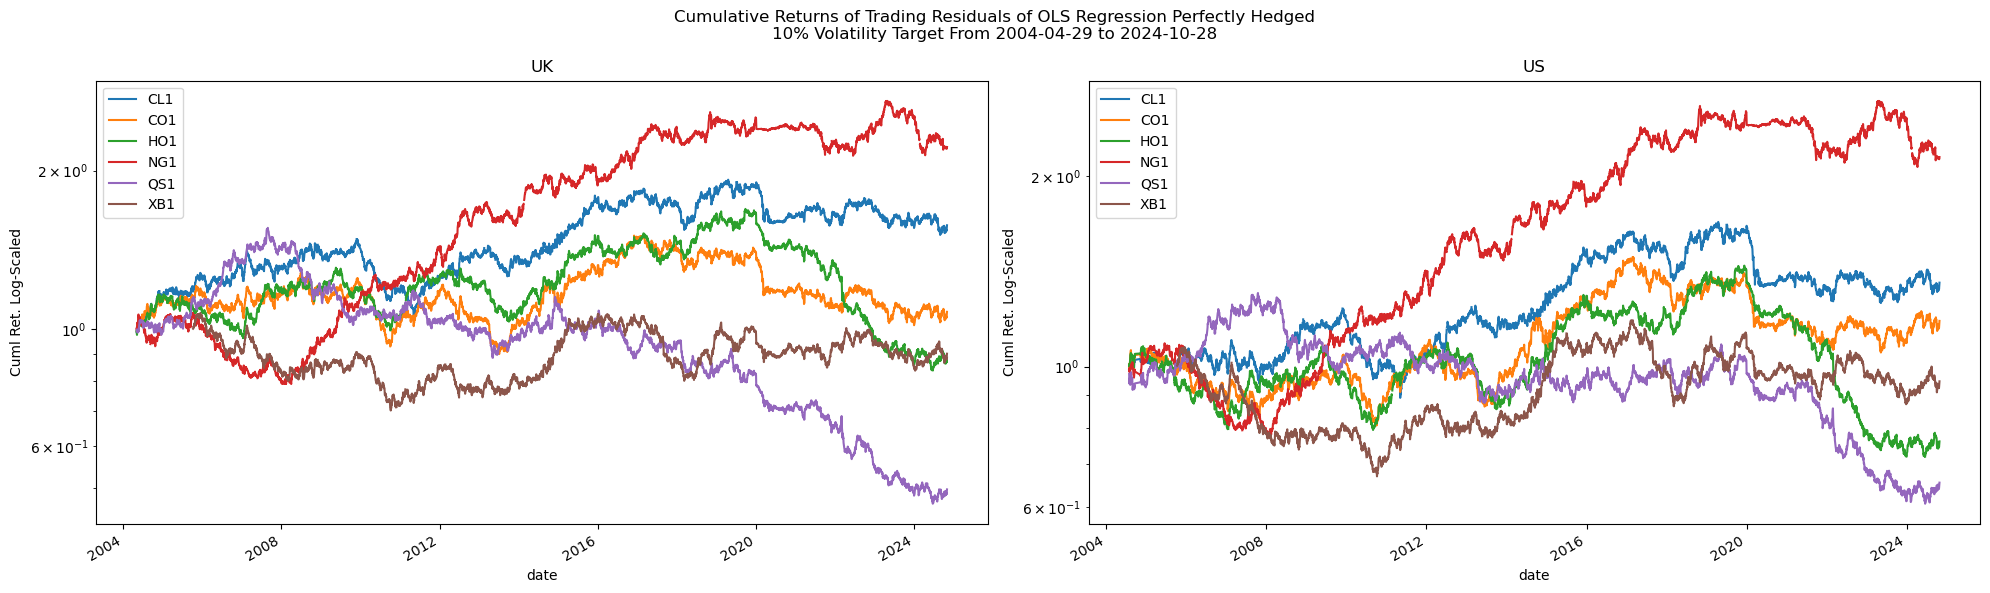

In [12]:
countrys  = df_ols.country.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(countrys), figsize = (20,6)) 

for country, ax in zip(countrys, axes.flatten()):

    (df_ols.assign(
        signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn).
        query("country == @country").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            title  = country,
            ylabel = "Cuml Ret. Log-Scaled"))
    
fig.suptitle("Cumulative Returns of Trading Residuals of OLS Regression Perfectly Hedged\n10% Volatility Target From {} to {}".format(
    df_ols.date.min().date(),
    df_ols.date.max().date()))

plt.tight_layout()

Below is a table of the sharpes for trading the residuals

# Section 3: Trading Residuals Cross-Sectionally

In [13]:
def _get_leg(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = (df.pivot(
        index = "date", columns = "security", values = "resid").
        dropna().
        T.
        apply(lambda x: pd.qcut(x = x, q = 2, labels = ["lower_group", "upper_group"])).
        T.
        shift().
        reset_index().
        melt(id_vars = "date"))

    return df_out

df_legs = (df_ols.groupby(
    "country").
    apply(_get_leg, include_groups = False).
    reset_index())

In [14]:
df_fut_wider = (df_fut_rtn.pivot(
    index = "date", columns = "security", values = "fut_rtn"))

df_perfect = (df_fut_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(vol = "perf"))

df_lagged = (df_fut_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(vol = "lagged"))

df_leg_single_rtn = (pd.concat([
    df_lagged, df_perfect]).
    merge(right = df_legs, how = "inner", on = ["date", "security"]).
    drop(columns = ["level_1"]))

In [15]:
df_leg_rtn = (df_leg_single_rtn.drop(
    columns = ["security"]).
    assign(rtn = lambda x: np.where(np.abs(x.rtn) > 1, np.nan, x.rtn)).
    groupby(["date", "vol", "country", "value"]).
    agg("mean").
    reset_index())

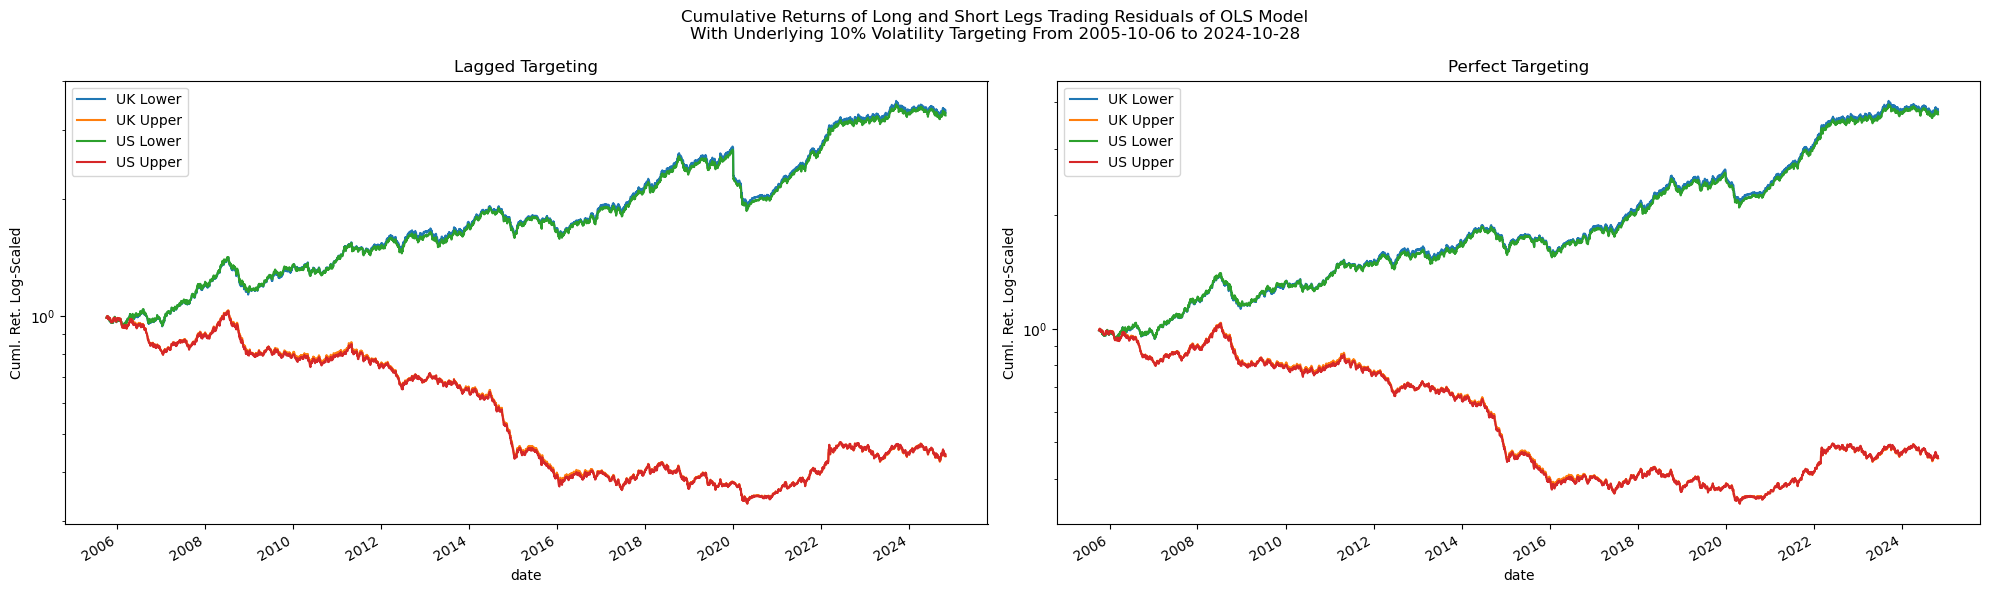

In [16]:
vols      = df_leg_rtn.vol.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(vols), figsize = (20,6))

renamer = {
    "lagged": "Lagged Targeting",
    "perf"  : "Perfect Targeting"}

for vol, ax in zip(vols, axes.flatten()): 

    (df_leg_rtn.query(
        "vol == @vol").
        assign(tmp = lambda x: x.country + " " + np.where(x.value.astype(str) == "lower_group", "Lower", "Upper")).
        rename(columns = {"tmp": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            title  = renamer[vol],
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Cumulative Returns of Long and Short Legs Trading Residuals of OLS Model\nWith Underlying 10% Volatility Targeting From {} to {}".format(
    df_leg_rtn.date.min().date(),
    df_leg_rtn.date.max().date()))

plt.tight_layout()
out_path = os.path.join("LaTex", "CrossSectionalLongShortLegPerf.png")
fig.savefig(fname = out_path, dpi = 300, bbox_inches = "tight")

In [17]:
df_leg_sharpe = (df_leg_rtn.drop(
    columns = ["date"]).
    groupby(["vol", "country", "value"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(value = lambda x: x.value.astype(str)).
    rename(columns = {
        "value": "",
        "vol"  : "Target"}).
    replace({
        "lagged": "Lagged",
        "perf"  : "Perfect",
        "lower_group": "Lower Group", 
        "upper_group": "Upper Group"}).
    pivot(index = "country", columns = ["Target", ""], values = "rtn").
    apply(lambda x: np.round(x,3)))

display(df_leg_sharpe)

Target       Lagged                 Perfect            
        Lower Group Upper Group Lower Group Upper Group
country                                                
UK            0.741      -0.485       0.896      -0.483
US            0.732      -0.485       0.887      -0.482

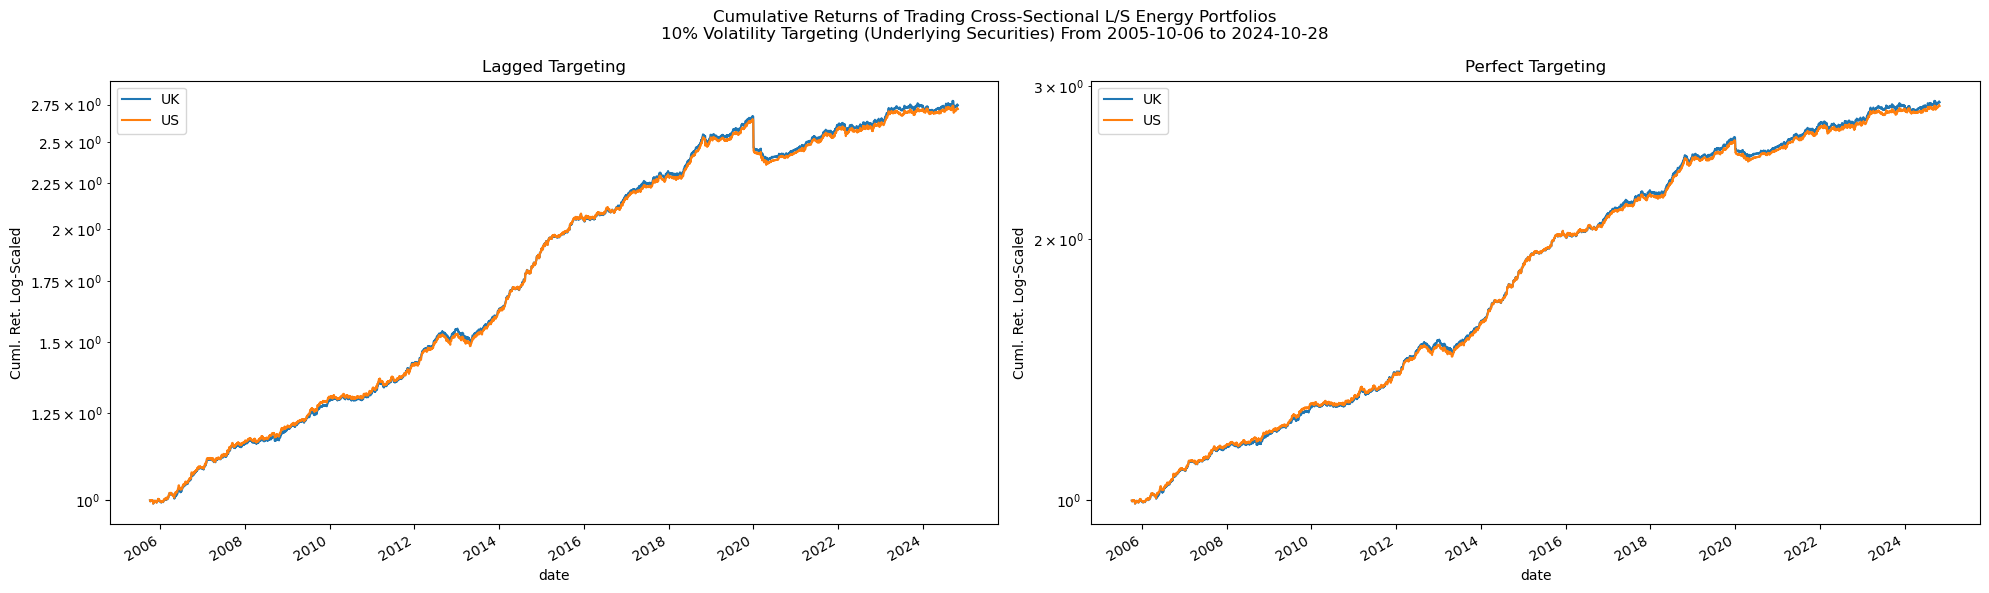

In [18]:
df_ls_rtn = (df_leg_rtn.pivot(
    index = ["date", "vol", "country"], columns = "value", values = "rtn").
    reset_index().
    assign(spread = lambda x: 0.5 * (x.lower_group - x.upper_group)))

vols      = df_ls_rtn.vol.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(vols), figsize = (20,6))

for vol, ax in zip(vols, axes.flatten()): 

    (df_ls_rtn.query(
        "vol == @vol").
        rename(columns = {"country": ""}).
        pivot(index = "date", columns = "", values = "spread").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = renamer[vol]))

fig.suptitle("Cumulative Returns of Trading Cross-Sectional L/S Energy Portfolios\n10% Volatility Targeting (Underlying Securities) From {} to {}".format(
    df_ls_rtn.date.min().date(),
    df_ls_rtn.date.max().date()))

plt.tight_layout()

In [19]:
df_cross = (df_ls_rtn[
    ["vol", "country", "spread"]].
    groupby(["vol", "country"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"vol": ""}).
    pivot(index = "country", columns = "", values = "spread").
    apply(lambda x: np.round(x,3)).
    rename(columns = {
        "lagged": "Lagged",
        "perf"  : "Perfect"}))

# Section 4: Trading Model based on Deciles of OLS Residuals

In [20]:
df_decile_sharpe = (df_ols[
    ["group_var", "decile", "fut_rtn"]].
    dropna().
    groupby(["group_var", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"fut_rtn": "sharpe"}))

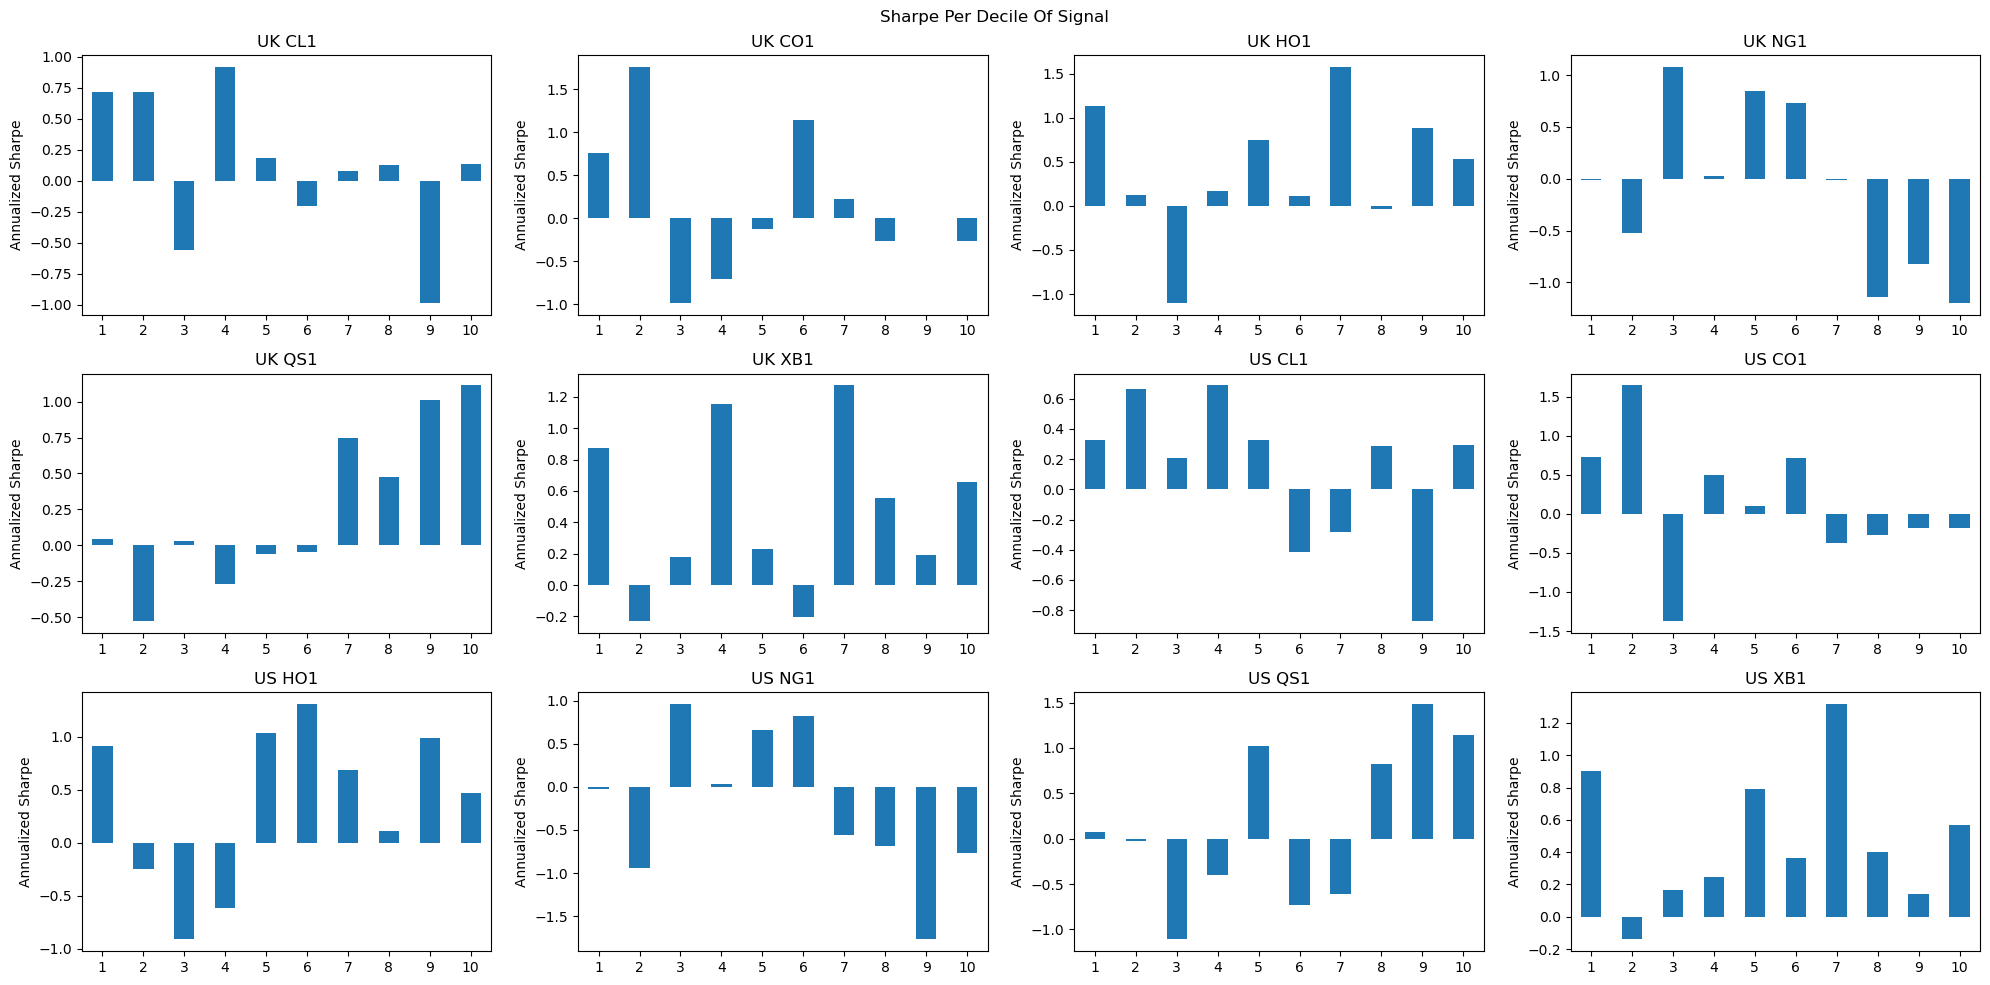

In [21]:
group_vars = df_decile_sharpe.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = 4, nrows = 3, figsize = (20,10))

for group_var, ax in zip(group_vars, axes.flatten()):
    
    (df_decile_sharpe.query(
        "group_var == @group_var").
         set_index("decile")
        [["sharpe"]].
        plot(
            ax     = ax,
            kind   = "bar", 
            ylabel = "Annualized Sharpe",
            title  = group_var,
            xlabel = "",
            rot    = 0,
            legend = False))
    
fig.suptitle("Sharpe Per Decile Of Signal")
plt.tight_layout()
fig.savefig(os.path.join(os.getcwd(), "LaTex", "OLSDecileSharpe.png"))

From the sharpes above we can see which tickers will have good returnn. HO and XB have weak bar charts and we'll likely find that the signal is not that good to trade. 

In [22]:
df_decile_group = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(tmp_group = lambda x: np.where(x.decile <= 2, "lower_group", "upper_group")))

In [23]:
df_decile_rtn = (df_decile_group.drop(
    columns = ["decile"]).
    groupby(["group_var", "tmp_group"]).
    agg("prod").
    rename(columns = {"sharpe": "scaler"}).
    reset_index().
    merge(right = df_decile_group, how = "inner", on = ["group_var", "tmp_group"]).
    assign(signal = lambda x: np.where(x.scaler > 0, np.sign(x.scaler * x.sharpe), 0))
    [["group_var", "decile", "signal"]].
    merge(right = df_ols, how = "outer", on = ["group_var", "decile"]).
    assign(
        signal     = lambda x: x.signal.fillna(0),
        signal_rtn = lambda x: np.sign(x.signal) * x.fut_rtn))

In [24]:
df_wider = (df_decile_rtn.pivot(
    index = "date", columns = ["security", "country"], values = "signal_rtn"))

In [25]:
df_lag = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", '')],  value_name = "signal_rtn").
    rename(columns = {("date", ''): "date"}).
    assign(group = "lag_vol"))

df_perf = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", '')],  value_name = "signal_rtn").
    rename(columns = {("date", ''): "date"}).
    assign(group = "perf_vol"))

df_stacked = (pd.concat([
    df_lag, df_perf]).
    dropna().
    assign(signal_rtn = lambda x: np.where(np.abs(x.signal_rtn) > 0.3, np.nan, x.signal_rtn)))

In [26]:
df_avg = (df_stacked.drop(
    columns = ["security"]).
    groupby(["date", "country", "group"]).
    agg("mean").
    reset_index().
    assign(security = "average"))

df_ex = (df_stacked.query(
    "security != ['HO1', 'XB1']").
    drop(columns = ["security"]).
    groupby(["date", "country", "group"]).
    agg("mean").
    reset_index().
    assign(security = "ex"))

df_combined = pd.concat([df_stacked, df_avg, df_ex])

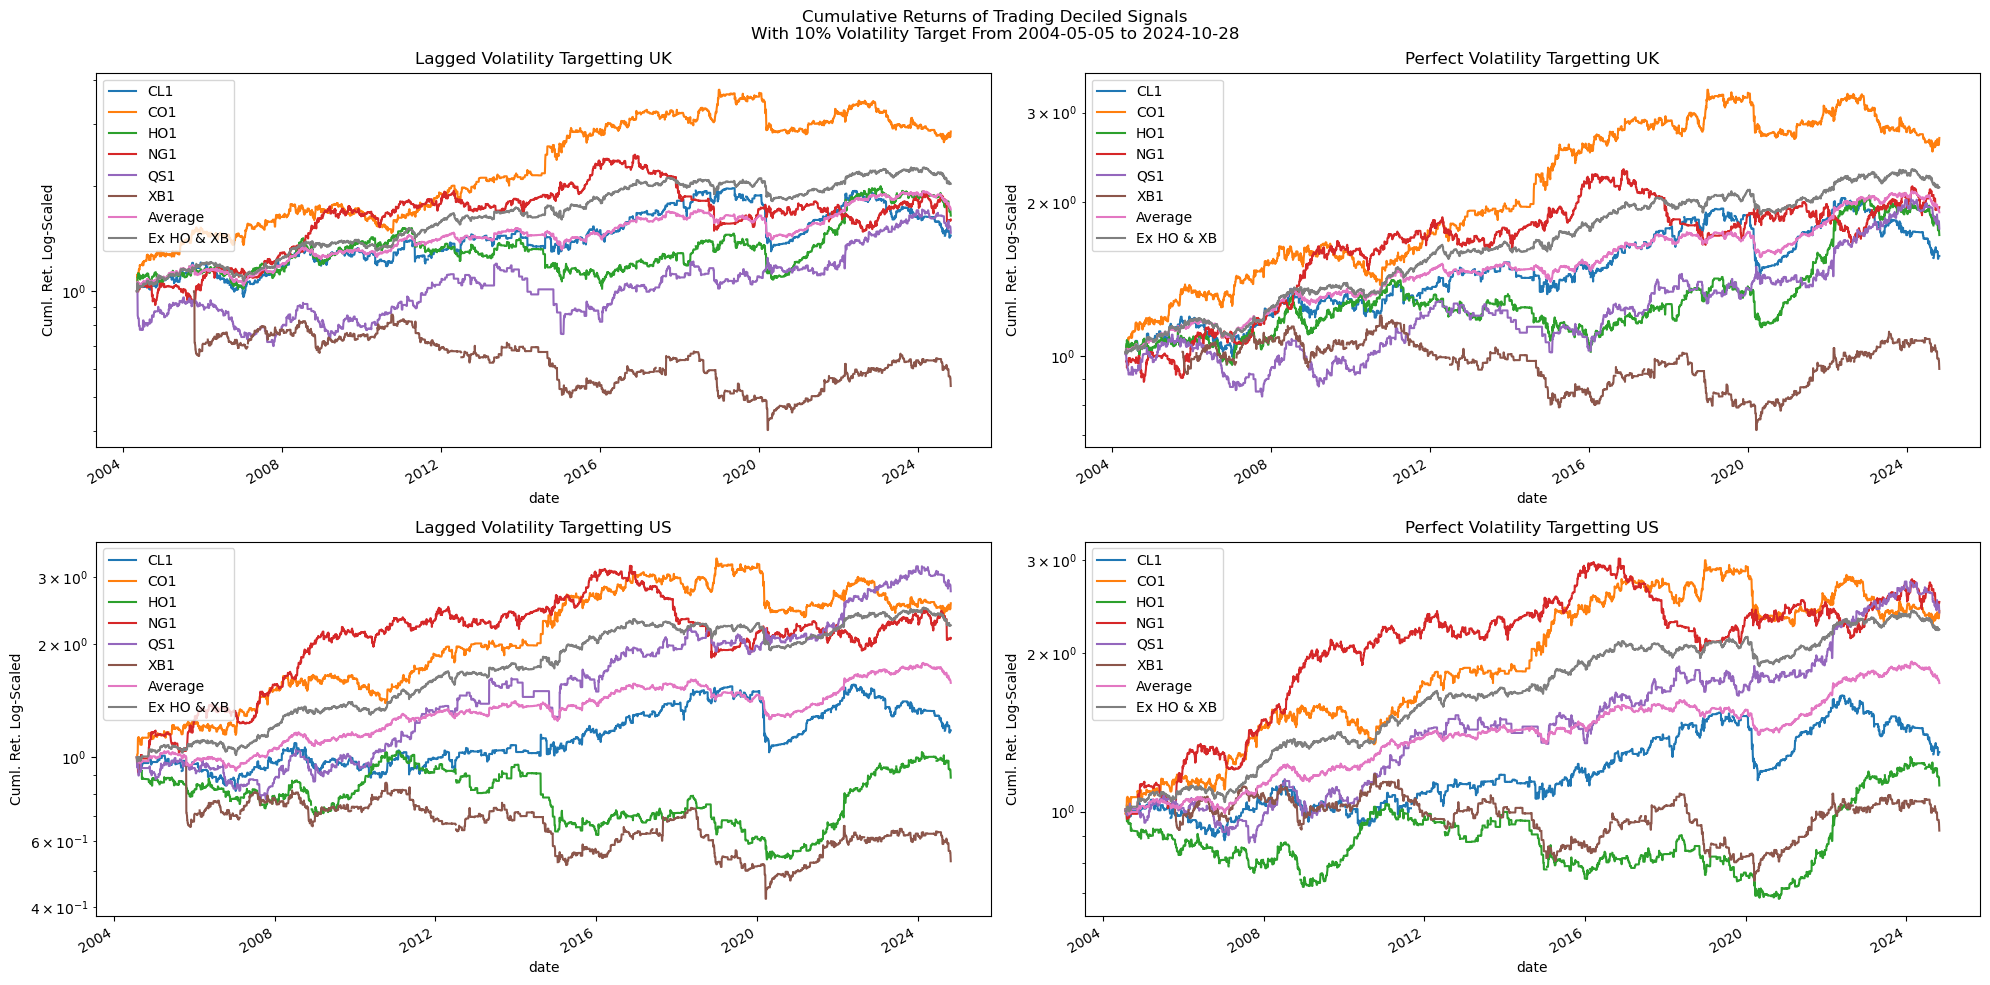

In [27]:
df_tmp = (df_combined.assign(
    group_var = lambda x: x.country + " " + x.group))

group_vars = df_tmp.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = 2, nrows = 2, figsize = (20,10))

renamer = {
    "lag_vol" : "Lagged Volatility Targetting",
    "perf_vol": "Perfect Volatility Targetting"}

for group_var, ax in zip(group_vars, axes.flatten()):
    
    (df_tmp.query(
        "group_var == @group_var").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        rename(columns = {
            "average": "Average",
            "ex"     : "Ex HO & XB"}).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True, 
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = renamer[group_var.split(" ")[1]] + " " + group_var.split(" ")[0]))
    
fig.suptitle("Cumulative Returns of Trading Deciled Signals\nWith 10% Volatility Target From {} to {}".format(
    df_tmp.date.min().date(),
    df_tmp.date.max().date()))

plt.tight_layout()

In [28]:
(df_combined.assign(
    adj_rtn = lambda x: np.where(x.signal_rtn == 0, np.nan, x.signal_rtn)).
    melt(id_vars = ["date", "security", "country", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["security", "country", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    replace({
        "average"   : "Average",
        "ex"        : "Ex HO & XB",
        "adj_rtn"   : "Adjusted Sharpe",
        "signal_rtn": "Raw Sharpe",
        "lag_vol"   : "Lag Targetting",
        "perf_vol"  : "Perfect Targetting"}).
    rename(columns = {
        "group"   : "Volatility Method",
        "variable": ""}).
    pivot(index = ["security", "country"], columns = ["Volatility Method", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Volatility Method   Lag Targetting            Perfect Targetting           
                   Adjusted Sharpe Raw Sharpe    Adjusted Sharpe Raw Sharpe
security   country                                                         
Average    UK                0.561      0.477              0.825      0.702
           US                0.535      0.451              0.811      0.683
CL1        UK                0.492      0.220              0.651      0.291
           US                0.293      0.131              0.426      0.191
CO1        UK                0.813      0.513              0.854      0.539
           US                0.761      0.481              0.785      0.495
Ex HO & XB UK                0.709      0.581              0.917      0.751
           US                0.834      0.684              0.988      0.809
HO1        UK                0.449      0.284              0.530      0.335
           US                0.003      0.001              0.245      0.110
NG1        UK                0.425      0.268              0.629      0.397
           US                0.608      0.384              0.846      0.533
QS1        UK                0.475      0.211              0.777      0.346
           US                1.040      0.462              1.154      0.513
XB1        UK               -0.419     -0.187              0.027      0.012
           US               -0.431     -0.192             -0.005     -0.002

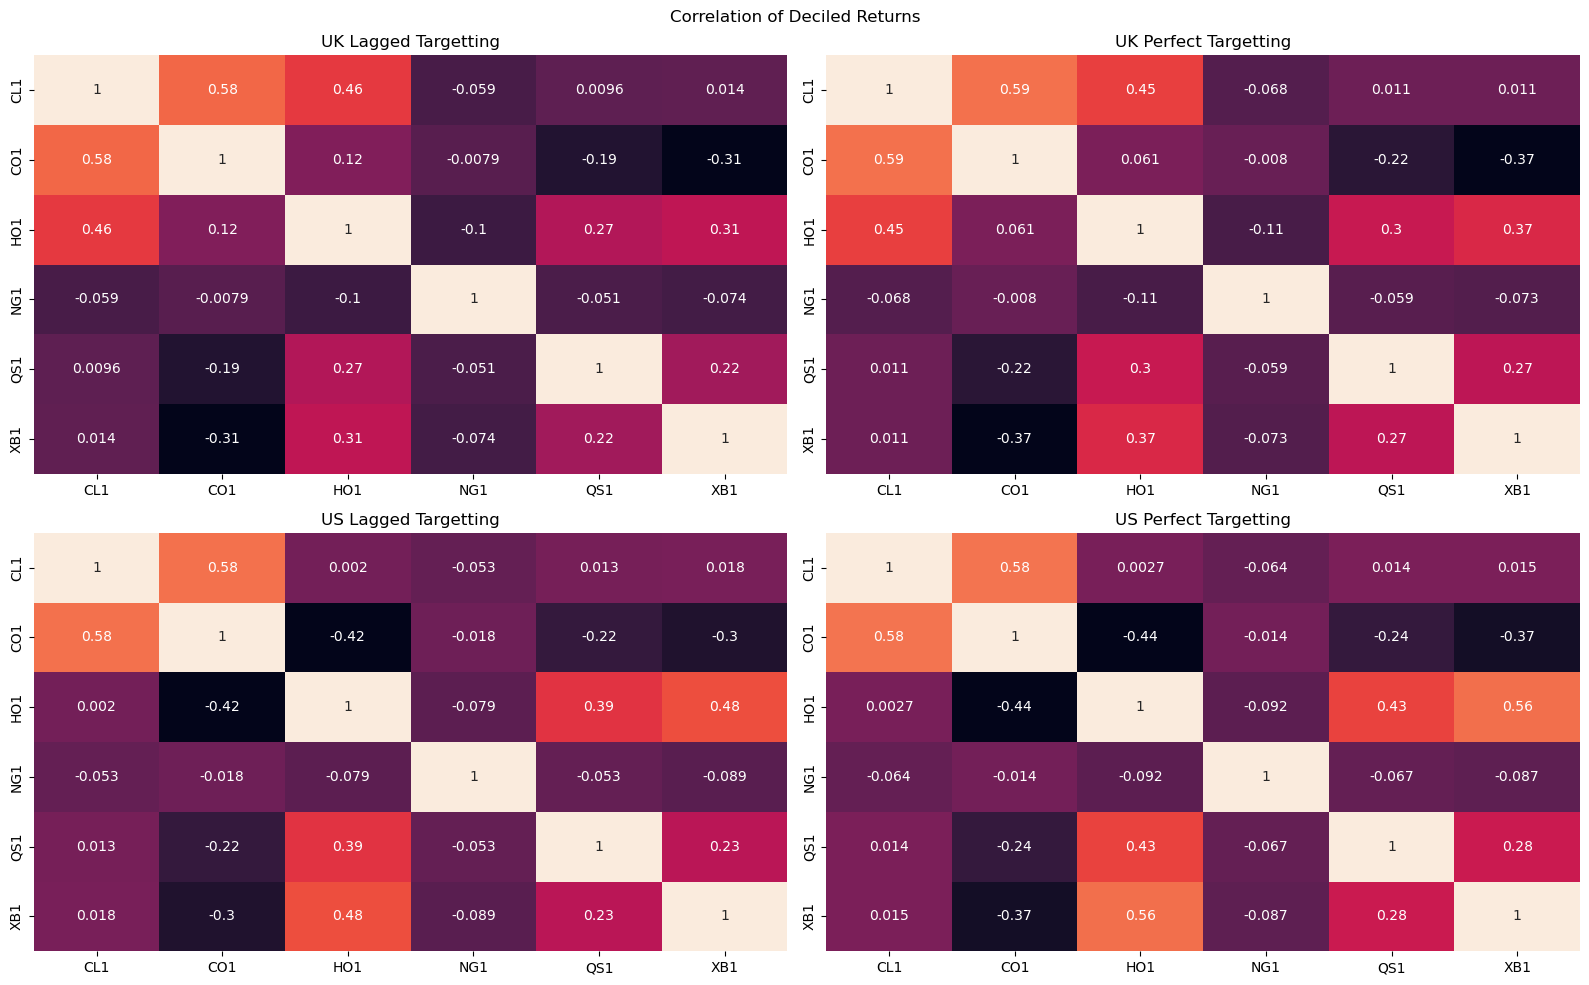

In [30]:
df_tmp = (df_combined.assign(
    group_var = lambda x: x.country + " " + x.group))

group_vars = df_tmp.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars) // 2, nrows = len(group_vars) // 2, figsize = (16,10))

renamer = {
    "lag_vol" : "Lagged Targetting",
    "perf_vol": "Perfect Targetting"}

for group_var, ax in zip(group_vars, axes.flatten()): 

    df_corr = (df_tmp.query(
        "group_var == @group_var").
        pivot(index = "date", columns = "security", values = "signal_rtn").
        drop(columns = ["average", "ex"]).
        corr())

    (sns.heatmap(
        ax    = ax,
        data  = df_corr,
        annot = True,
        cbar  = False))

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(
        group_var.split(" ")[0] + 
        " " + 
        renamer[group_var.split(" ")[1]])

fig.suptitle("Correlation of Deciled Returns")
plt.tight_layout()

In [31]:
renamer = {
    "lag_vol" : "Lagged Vol",
    "perf_vol": "Perfect Vol",
    "raw"     : "Raw Return"}

In [32]:
df_tmp_corr = (df_combined.pivot(
    index = ["date", "country", "group"], columns = "security", values = "signal_rtn").
    reset_index().
    drop(columns = ["date", "average", "ex"]).
    groupby(["country", "group"]).
    agg("corr").
    reset_index().
    rename(columns = {"security": "security1"}).
    melt(id_vars = ["country", "group", "security1"]).
    query("security1 != security").
    drop(columns = ["security", "security1"]).
    groupby(["country", "group"]).
    agg("mean").
    reset_index().
    replace(renamer).
    assign(group = lambda x: x.country + "\n" + x.group)
    [["group", "value"]])

In [33]:
df_wider = (df_fut_rtn.pivot(
    index = "date", columns = "security", values = "fut_rtn"))

df_lag_vol = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "fut_rtn").
    assign(group = "lag_vol").
    dropna())

df_perf_vol = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "fut_rtn").
    assign(group = "perf_vol").
    dropna())

In [34]:
df_baseline = (pd.concat([
    df_fut_rtn.assign(group = "raw"),
    df_lag_vol,
    df_perf_vol]).
    pivot(index = ["date", "group"], columns = "security", values = "fut_rtn").
    reset_index().
    drop(columns = ["date"]).
    groupby("group").
    agg("corr").
    reset_index().
    rename(columns = {"security": "security1"}).
    melt(id_vars = ["group", "security1"]).
    query("value != 1")
    [["group", "value"]].
    groupby("group").
    agg("mean").
    reset_index().
    replace(renamer))

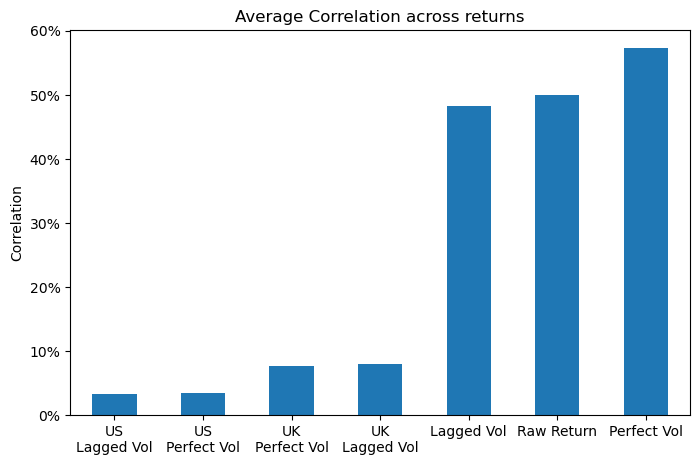

In [35]:
fig, axes = plt.subplots(figsize = (8,5))

(pd.concat([
    df_tmp_corr, df_baseline]).
    sort_values("value").
    set_index("group").
    plot(
        ax     = axes,
        kind   = "bar",
        rot    = 0,
        xlabel = "",
        legend = False,
        ylabel = "Correlation",
        title  = "Average Correlation across returns"))

axes.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

# Section 5: Trading Z-Score of the 5y5y Forward Inflation

In [36]:
window = 30

df_decile = (df_inf.pivot(
    index = "date", columns = "country", values = "value").
    apply(lambda x: np.log(x).diff()).
    apply(lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std()).
    apply(lambda x: pd.qcut(x = x, q = 10, labels = [i + 1 for i in range(10)])).
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "decile").
    dropna())

In [37]:
df_combined = (df_fut_rtn.merge(
    right = df_decile, how = "inner", on = ["date"]))

In [38]:
df_decile_sharpe = (df_combined.drop(
    columns = ["date"]).
    groupby(["security", "country", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index())

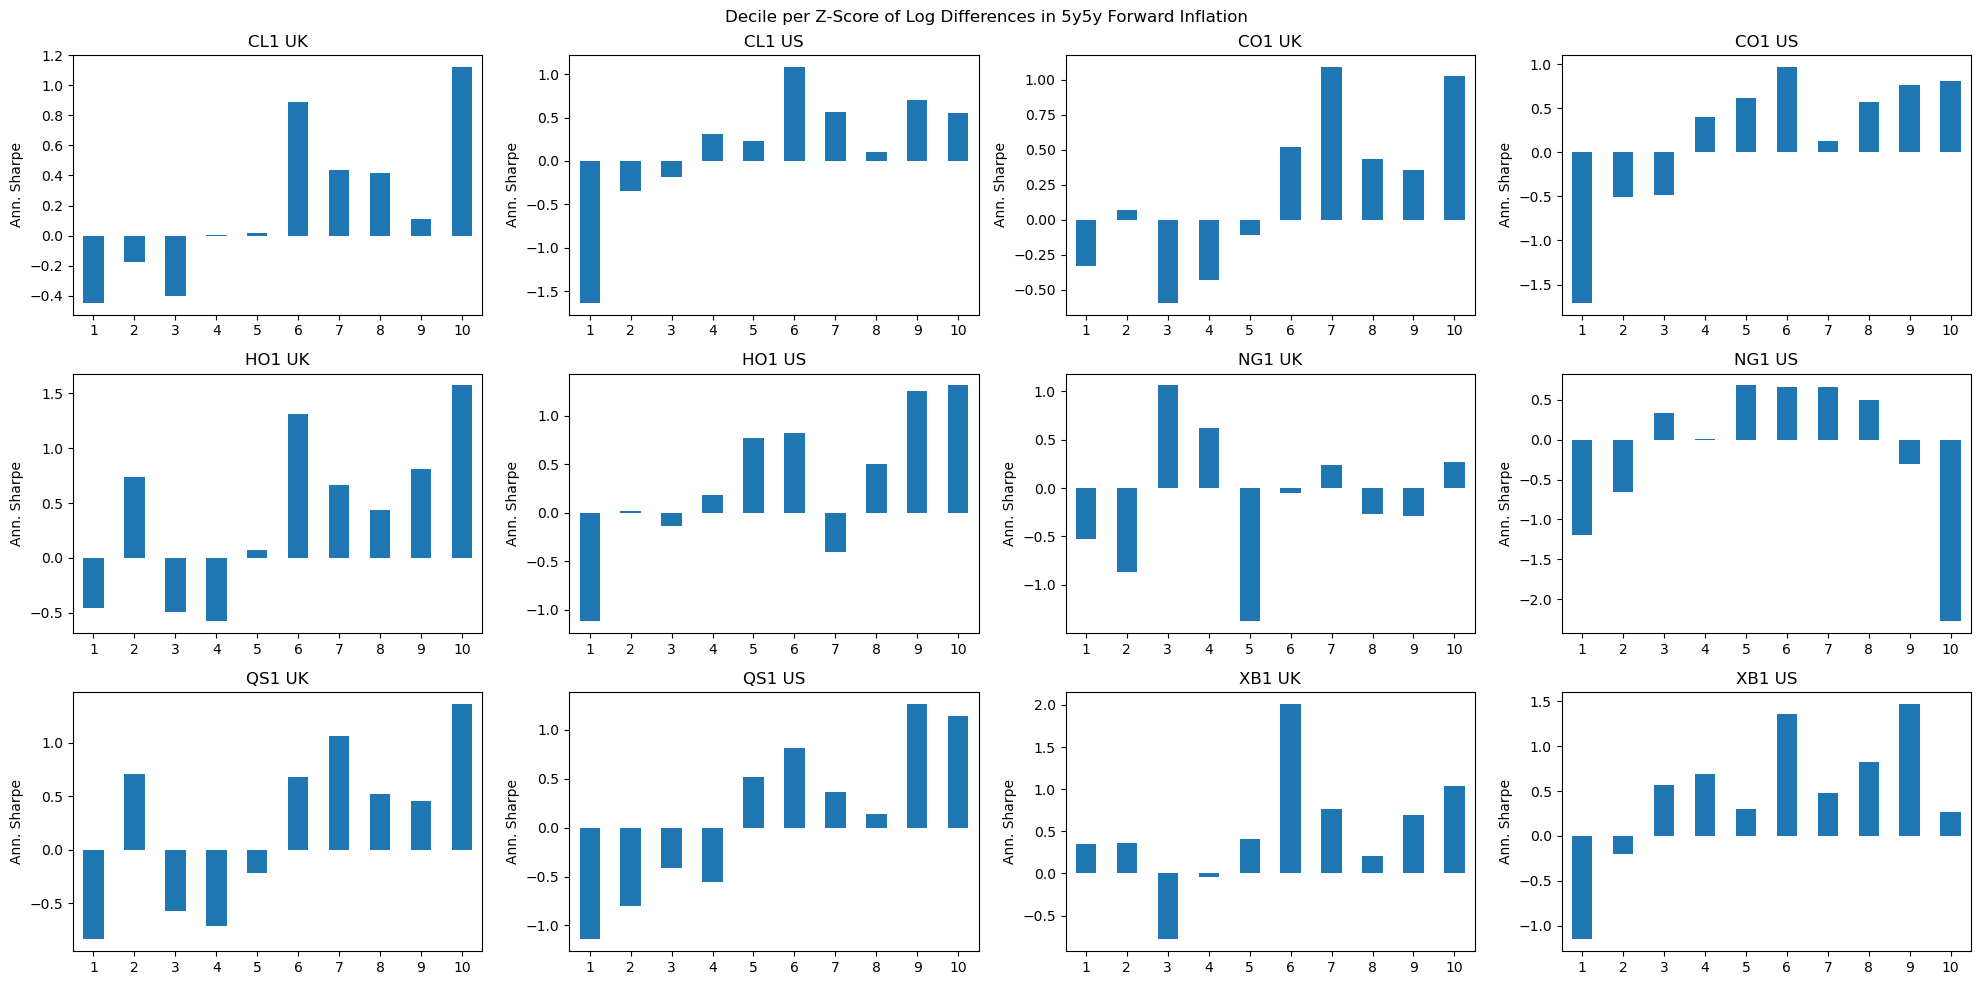

In [39]:
df_tmp = (df_decile_sharpe.assign(
    group_var = lambda x: x.security + " " + x.country))

group_vars = df_tmp.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars) // 3, nrows = len(group_vars) // 4, figsize = (20,10))

for group_var, ax in zip(group_vars, axes.flatten()):
    
    (df_tmp.query(
        "group_var == @group_var").
        set_index("decile")
        [["fut_rtn"]].
        plot(
            ax     = ax,
            kind   = "bar",
            rot    = 0,
            legend = False,
            xlabel = "",
            ylabel = "Ann. Sharpe",
            title  = group_var))

fig.suptitle("Decile per Z-Score of Log Differences in 5y5y Forward Inflation")
plt.tight_layout()

In [40]:
df_decile_group = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(decile_group = lambda x: np.where(x.decile <= 2, "lower_group", "upper_group")))

In [41]:
df_decile_rtn = (df_decile_group.drop(
    columns = ["decile"]).
    groupby(["security", "country", "decile_group"]).
    agg("prod").
    reset_index().
    assign(scaler = lambda x: np.where(x.fut_rtn > 0, 1, 0)).
    drop(columns = ["fut_rtn"]).
    merge(right = df_decile_group, how = "inner", on = ["security", "country", "decile_group"]).
    rename(columns = {"fut_rtn": "sharpe"}).
    merge(right = df_combined, how = "outer", on = ["security", "country", "decile"]).
    drop(columns = ["decile_group"]).
    assign(signal_rtn = lambda x: np.sign(x.sharpe * x.scaler) * x.fut_rtn))

In [42]:
df_wider = (df_decile_rtn.pivot(
    index = "date", columns = ["security", "country"], values = "signal_rtn"))

df_perf = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    assign(target = "perfect"))

df_lagged = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.20, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    assign(target = "lagged"))

df_decile_combined = (pd.concat([
    df_perf, df_lagged]).
    assign(group_var = lambda x: x.country + " " + x.target))

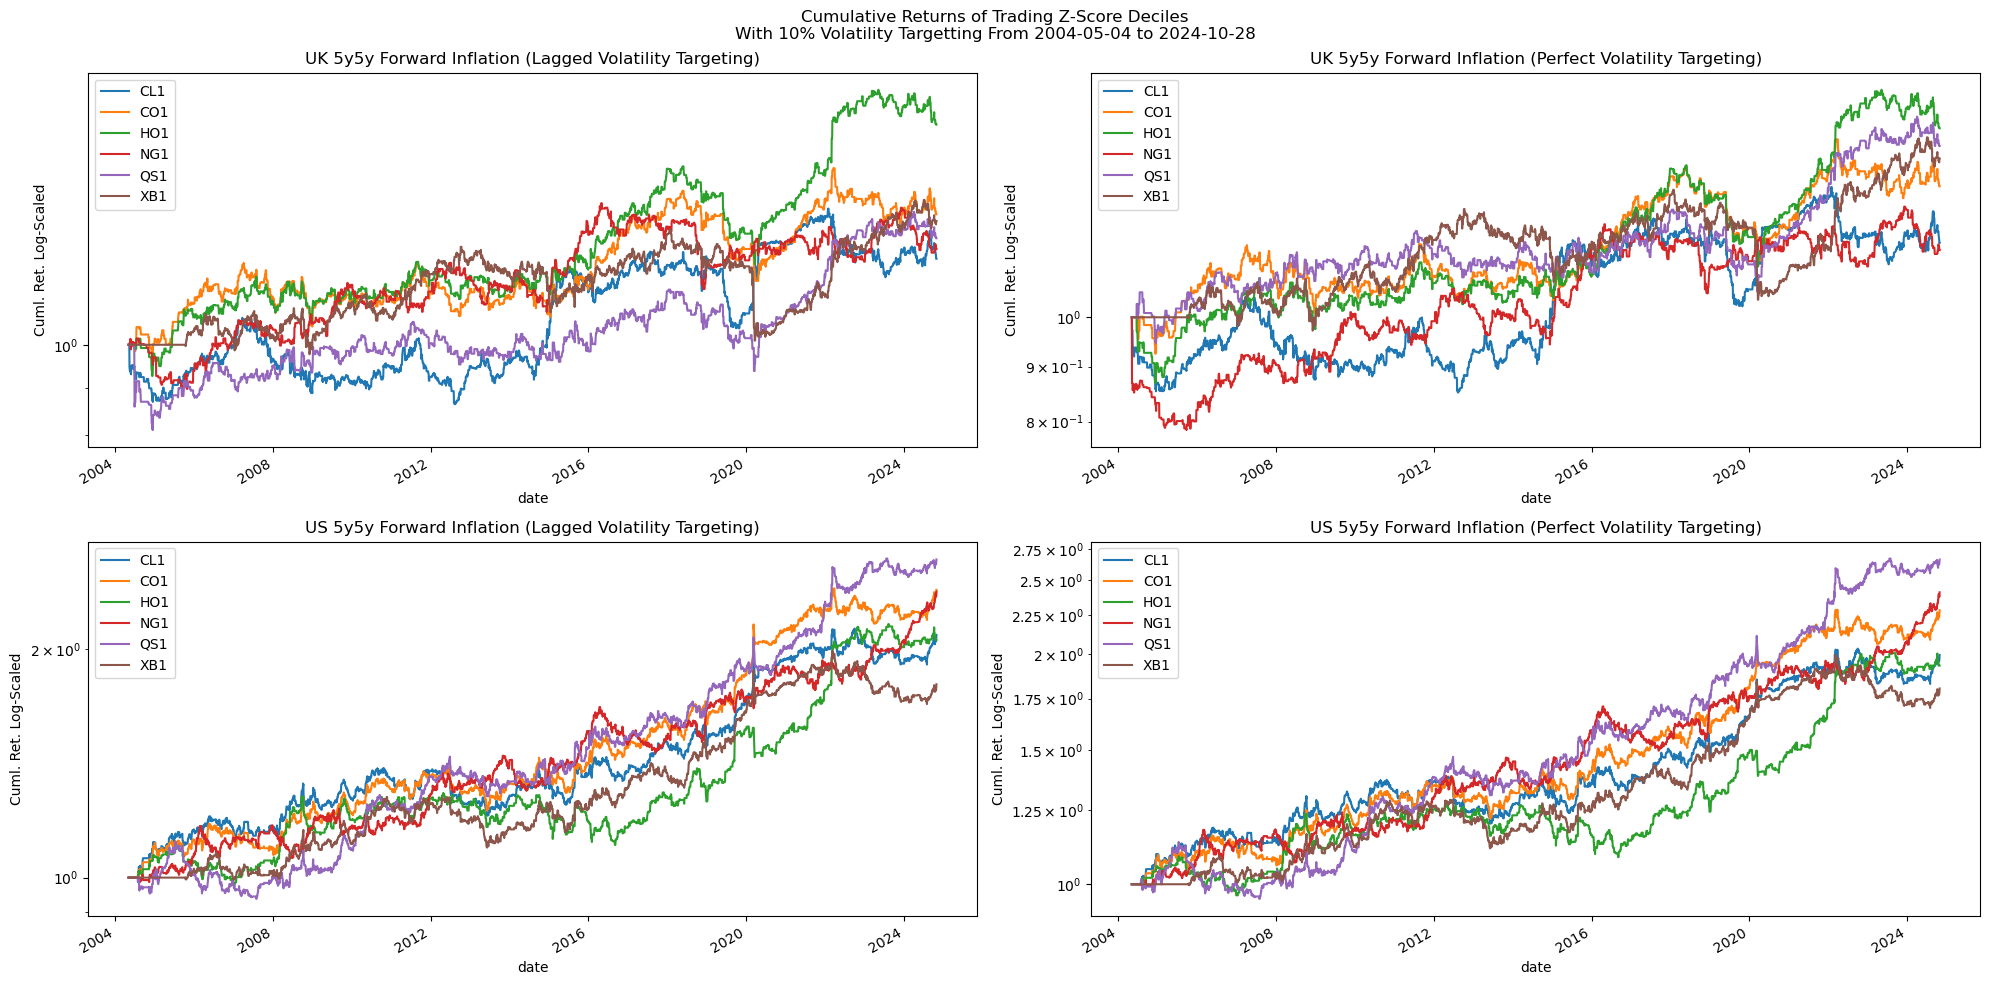

In [44]:
group_vars = df_decile_combined.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars) // 2, nrows = len(group_vars) // 2, figsize = (20,10))

for group_var, ax in zip(group_vars, axes.flatten()): 


    country, vol = group_var.split(" ")
    
    (df_decile_combined.query(
        "group_var == @group_var").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "value").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            title  = "{} 5y5y Forward Inflation ({} Volatility Targeting)".format(
                country, vol.capitalize()),
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Cumulative Returns of Trading Z-Score Deciles\nWith 10% Volatility Targetting From {} to {}".format(
    df_decile_combined.date.min().date(),
    df_decile_combined.date.max().date()))

plt.tight_layout()

In [45]:
(df_decile_combined.drop(
    columns = ["group_var"]).
    rename(columns = {"value": "adj_rtn"}).
    assign(raw_rtn = lambda x: x.adj_rtn.fillna(0)).
    melt(id_vars = ["date", "country", "security", "target"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["security", "country", "target", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "target"  : "Vol. Target",
        "variable": ""}).
    replace({
        "lagged" : "Lagged",
        "perfect": "Perfect",
        "adj_rtn": "Adj Sharpe",
        "raw_rtn": "Raw Sharpe"}).
    pivot(index = ["security", "country"], columns = ["Vol. Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Vol. Target          Lagged               Perfect           
                 Adj Sharpe Raw Sharpe Adj Sharpe Raw Sharpe
security country                                            
CL1      UK           0.303      0.187      0.249      0.154
         US           0.955      0.582      0.947      0.577
CO1      UK           0.418      0.263      0.391      0.246
         US           1.073      0.669      1.075      0.670
HO1      UK           0.688      0.424      0.560      0.346
         US           0.926      0.564      0.933      0.569
NG1      UK           0.326      0.202      0.220      0.136
         US           1.140      0.694      1.189      0.724
QS1      UK           0.326      0.206      0.494      0.311
         US           1.178      0.734      1.250      0.779
XB1      UK           0.443      0.267      0.503      0.304
         US           0.830      0.494      0.871      0.518

Below is a table of the correlation matrix of the returns. 

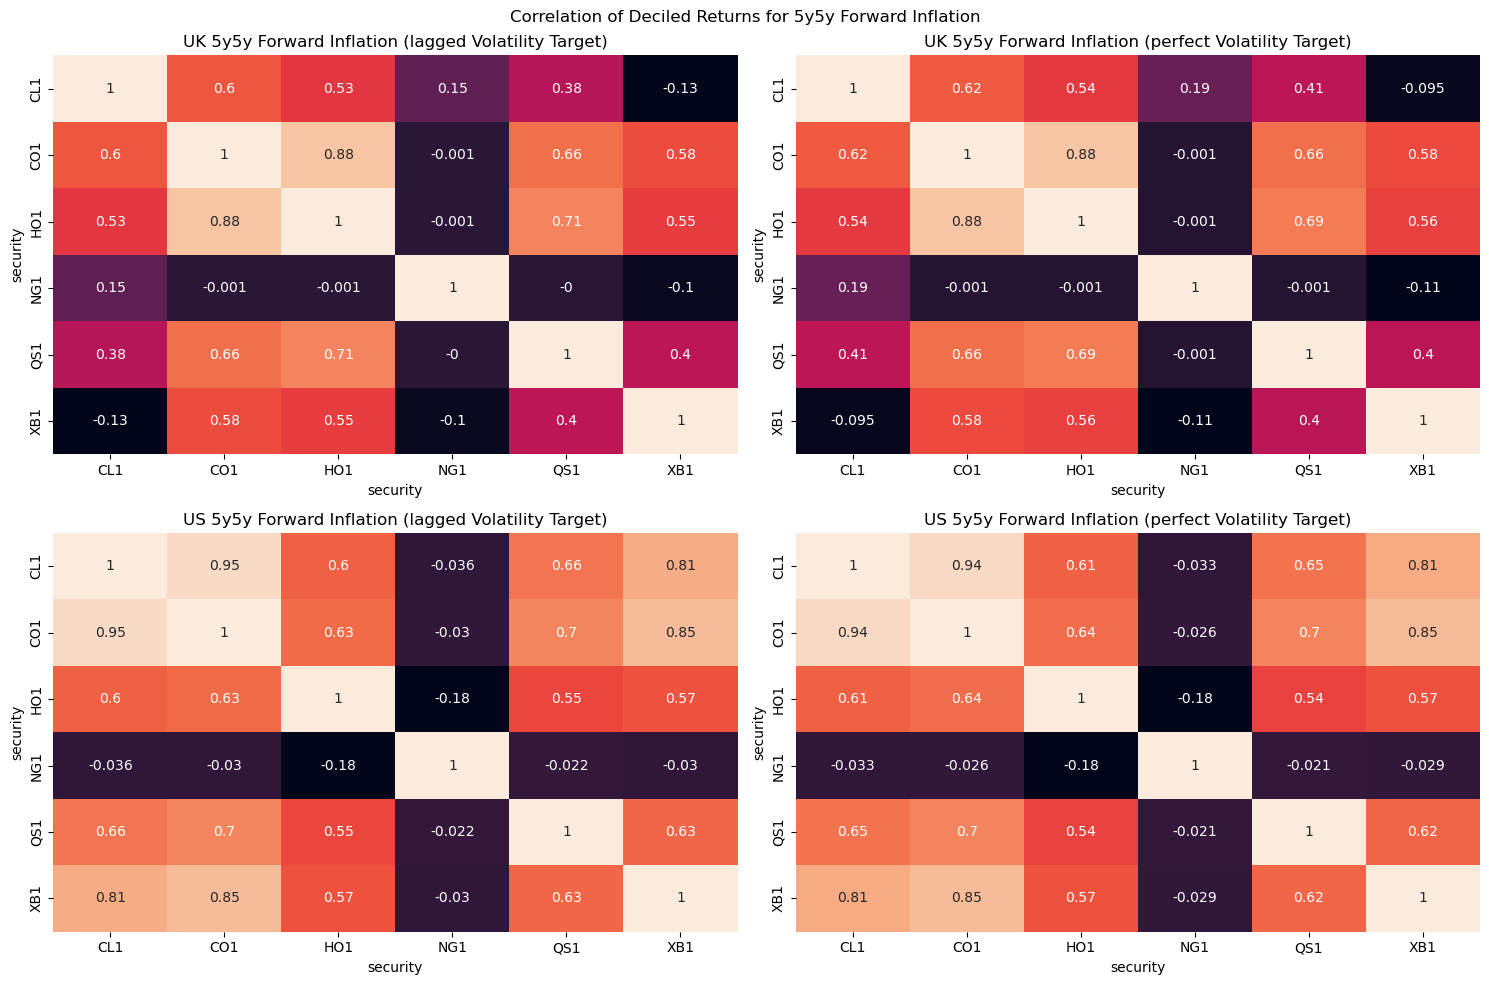

In [49]:
group_vars = df_decile_combined.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars) // 2, nrows = len(group_vars) // 2, figsize = (15,10))

for group_var, ax in zip(group_vars, axes.flatten()): 

    country, vol = group_var.split(" ")
    
    df_corr = (df_decile_combined.query(
        "group_var == @group_var").
        pivot(index = "date", columns = "security", values = "value").
        corr().
        apply(lambda x: np.round(x,3)))
    
    sns.heatmap(
        data  = df_corr,
        ax    = ax,
        cbar  = False,
        annot = True)
    
    ax.set_title("{} 5y5y Forward Inflation ({} Volatility Target)".format(
        country, vol))
    
fig.suptitle("Correlation of Deciled Returns for 5y5y Forward Inflation")
plt.tight_layout()

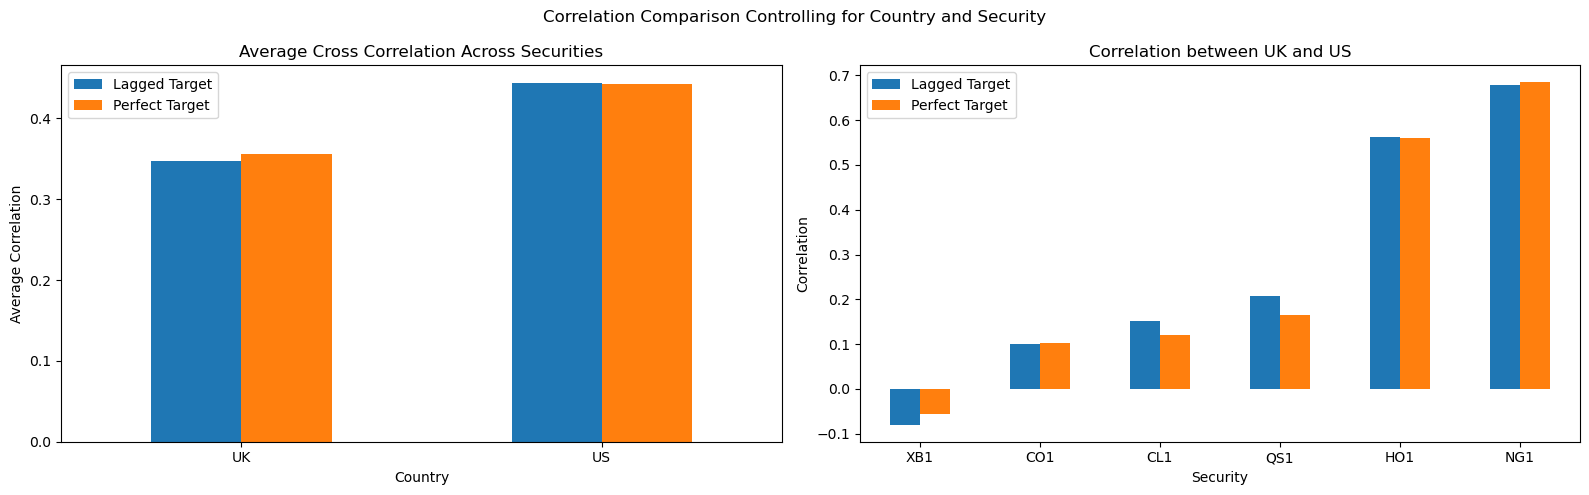

In [50]:
fig, axes = plt.subplots(ncols = 2, figsize = (16,5))

(df_decile_combined.pivot(
    index = ["date", "country", "target"], columns = "security", values = "value").
    reset_index().
    drop(columns = ["date"]).
    groupby(["country", "target"]).
    agg("corr").
    reset_index().
    rename(columns = {"security": "security1"}).
    melt(id_vars = ["country", "security1", "target"]).
    query("security1 != security")
    [["country", "target", "value"]].
    groupby(["country", "target"]).
    agg("mean").
    reset_index().
    assign(target = lambda x: x.target.str.capitalize() + " Target").
    rename(columns = {"target": ""}).
    pivot(index = "country", columns = "", values = "value").
    plot(
        kind = "bar",
        ax   = axes[0],
        xlabel = "Country",
        ylabel = "Average Correlation",
        rot    = 0,
        title  = "Average Cross Correlation Across Securities"))

(df_decile_combined.pivot(
    index = ["date", "security", "target"], columns = "country", values = "value").
    reset_index().
    drop(columns = ["date"]).
    groupby(["security", "target"]).
    agg("corr").
    drop(columns = ["US"]).
    query("UK != 1").
    reset_index().
    assign(target = lambda x: x.target.str.capitalize() + " Target").
    rename(columns = {"target": ""}).
    pivot(index = "security", columns = "", values = "UK").
    sort_values("Lagged Target").
    plot(
        kind   = "bar", 
        ax     = axes[1],
        rot    = 0,
        xlabel = "Security",
        title  = "Correlation between UK and US",
        ylabel = "Correlation"))

fig.suptitle("Correlation Comparison Controlling for Country and Security")
plt.tight_layout()

In [51]:
df_decile_port = (df_decile_combined[
    ["date", "country", "target", "value"]].
    groupby(["date", "country", "target"]).
    agg("mean").
    reset_index().
    pivot(index = ["date", "target"], columns = "country", values = "value").
    assign(Combo = lambda x: x.mean(axis = 1)).
    reset_index().
    melt(id_vars = ["date", "target"]).
    dropna())

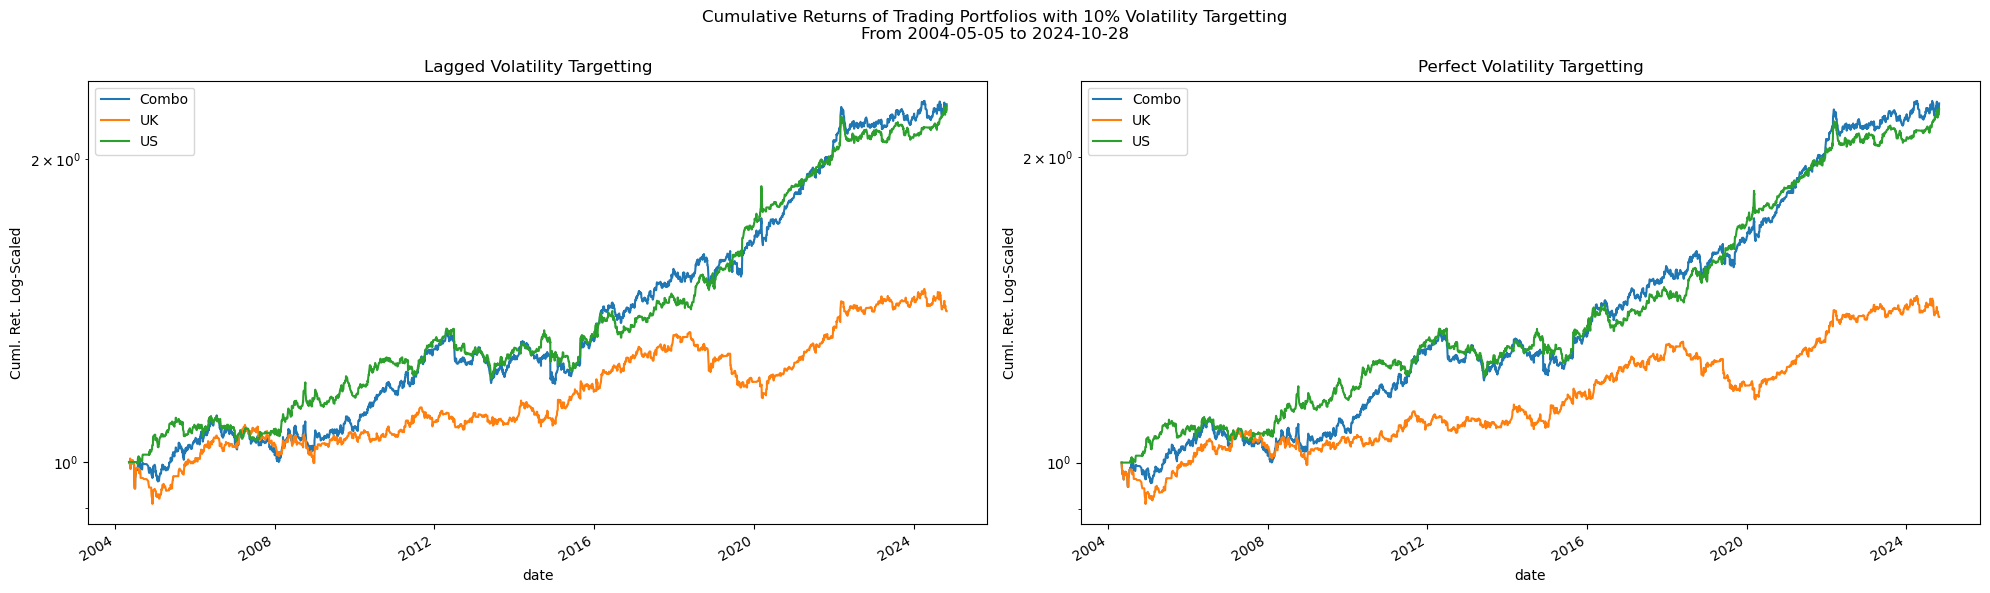

In [52]:
group_vars = df_decile_port.target.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_decile_port.query(
        "target == @group_var").
        rename(columns = {"country": ""}).
        assign(value = lambda x: np.where(x.date == x.date.min(), 0, x.value)).
        pivot(index = "date", columns = "", values = "value").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = "{} Volatility Targetting".format(group_var.capitalize())))

fig.suptitle("Cumulative Returns of Trading Portfolios with 10% Volatility Targetting\nFrom {} to {}".format(
    df_decile_port.date.min().date(),
    df_decile_port.date.max().date()))

plt.tight_layout()

In [53]:
(df_decile_port.drop(
    columns = ["date"]).
    groupby(["target", "country"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(target = lambda x: x.target.str.capitalize() + " Volatility").
    rename(columns = {"country": ""}).
    pivot(index = "", columns = "target", values = "value").
    apply(lambda x: np.round(x,3)))

target,Lagged Volatility,Perfect Volatility
,,
Combo,0.828,0.830
UK,0.490,0.436
US,1.319,1.384


# Section 6: Combining all the strategies 

In [54]:
replacer = {
    "perf"    : "perfect",
    "perf_vol": "perfect",
    "lag_vol" : "lagged"}

In [55]:
df_ls_tmp = (df_ls_rtn.query(
    "country == 'US'")
    [["spread", "vol", "date"]].
    rename(columns = {"spread": "value"}).
    replace(replacer).
    assign(strat = "ls_spread"))

In [59]:
df_decile_ols = (df_ex.assign(
    strat = lambda x: x.country + "_decile_ols")
    [["date", "strat", "signal_rtn", "group"]].
    rename(columns = {
        "signal_rtn": "value",
        "group"     : "vol"}).
    replace(replacer))

In [60]:
df_zscore = (df_decile_port.query(
    "country == 'US'").
    assign(strat = "zscore").
    rename(columns = {"target": "vol"}).
    drop(columns = ["country"]))

In [62]:
df_port = (pd.concat([
    df_ls_tmp, df_decile_ols, df_zscore]).
    replace({
        "ls_spread"     : "L/S Spread",
        "UK_decile_ols" : "UK Decile OLS",
        "US_decile_ols" : "US Decile OLS",
        "zscore"        : "Z-Score"}))

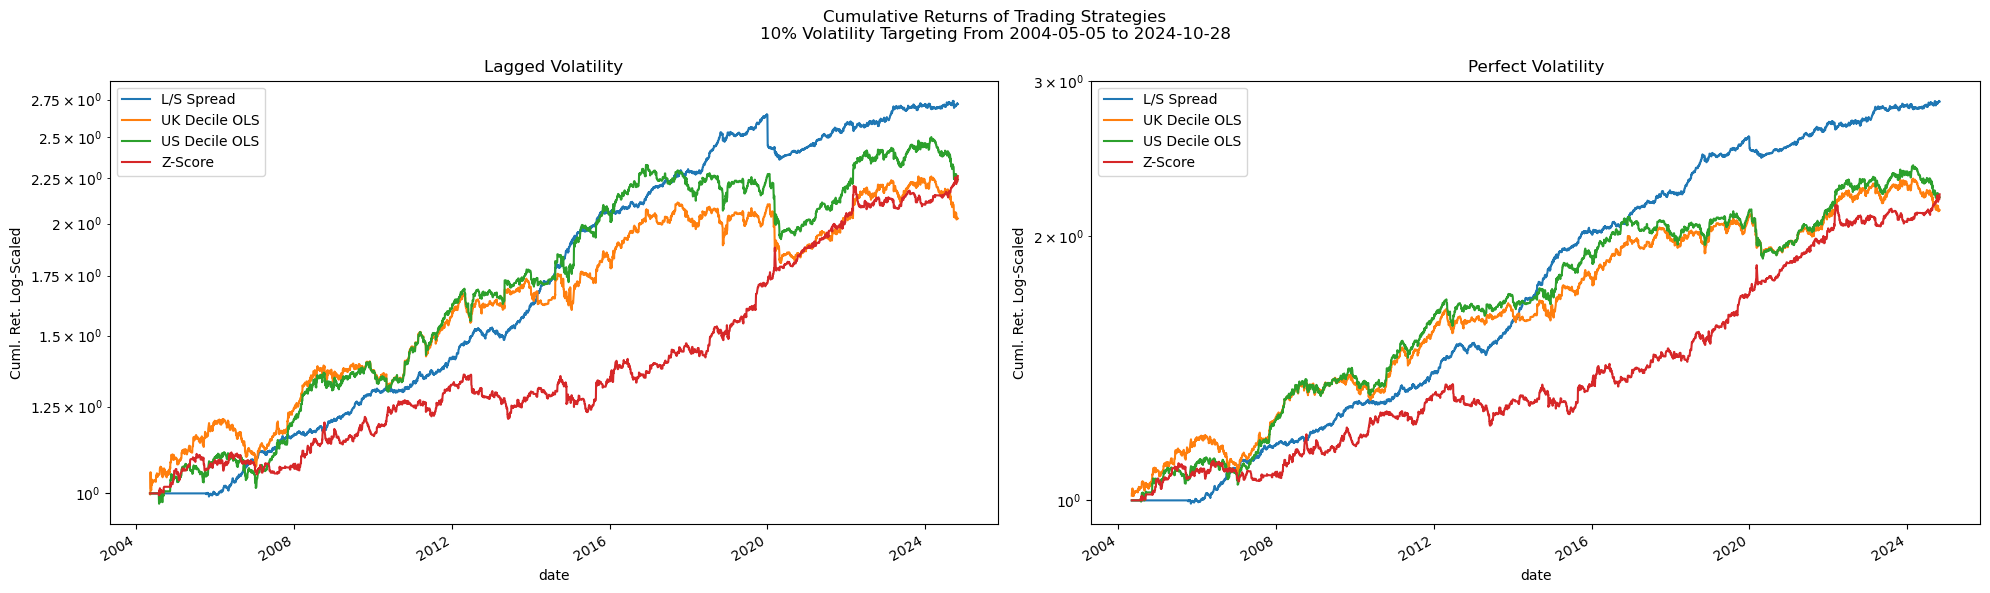

In [63]:
vols      = df_port.vol.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(vols), figsize = (20,6))

for vol, ax in zip(vols, axes.flatten()): 

    (df_port.query(
        "vol == @vol")
        [["date", "strat", "value"]].
        assign(date = lambda x: pd.to_datetime(x.date)).
        rename(columns = {"strat": ""}).
        pivot(index = "date", columns = "", values = "value").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = vol.capitalize() + " Volatility"))

fig.suptitle("Cumulative Returns of Trading Strategies\n10% Volatility Targeting From {} to {}".format(
    df_port.date.min().date(),
    df_port.date.max().date()))
plt.tight_layout()

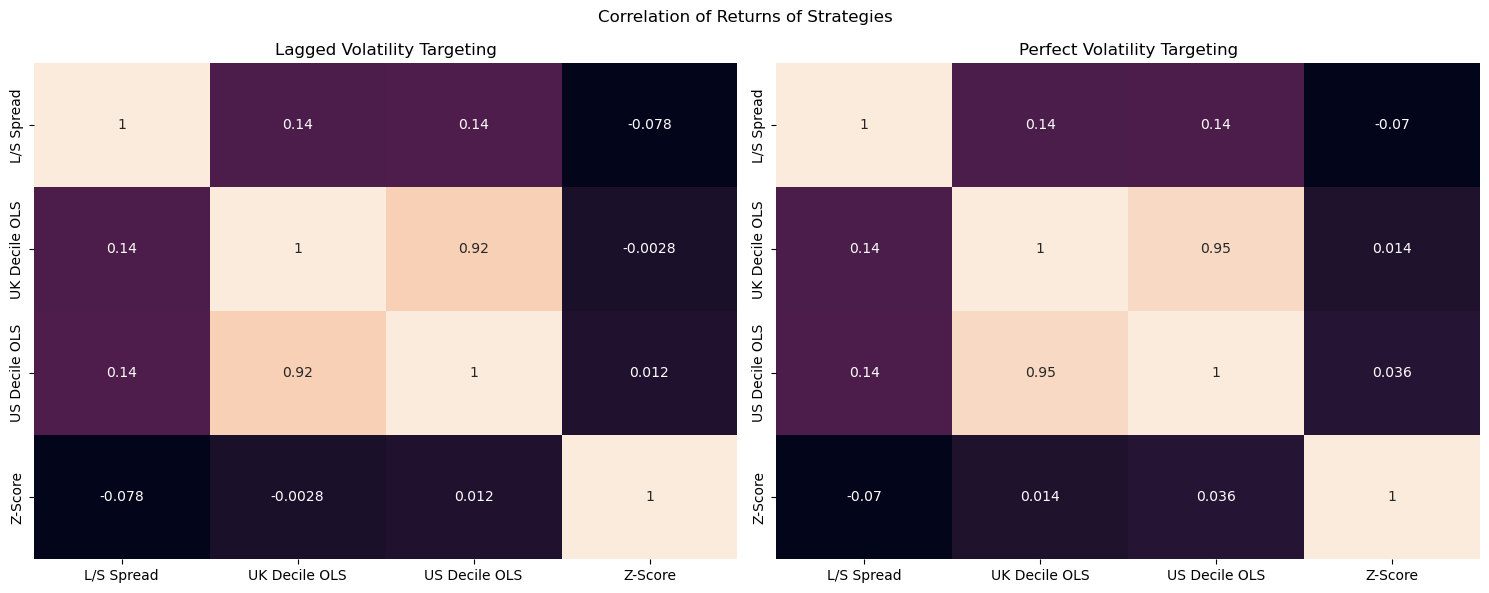

In [64]:
group_vars = df_port.vol.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (15,6))

for group_var, ax in zip(group_vars, axes.flatten()): 

    df_corr = (df_port.query(
        "vol == @group_var").
        pivot(index = "date", columns = "strat", values = "value").
        corr())

    sns.heatmap(
        data  = df_corr,
        ax    = ax,
        cbar  = False,
        annot = True)

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(group_var.capitalize() + " Volatility Targeting")

fig.suptitle("Correlation of Returns of Strategies")
plt.tight_layout()

In [65]:
(df_port.drop(
    columns = ["date"]).
    groupby(["strat", "vol"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "strat": "",
        "vol"  : "Vol Target"}).
    pivot(index = "", columns = "Vol Target", values = "value").
    apply(lambda x: np.round(x,3)))

Vol Target,lagged,perfect
,,
L/S Spread,1.653,2.054
UK Decile OLS,0.581,0.751
US Decile OLS,0.684,0.809
Z-Score,1.319,1.384


In [66]:
df_avg_port = (df_port.drop(
    columns = ["strat"]).
    groupby(["date", "vol"]).
    agg("mean").
    reset_index())

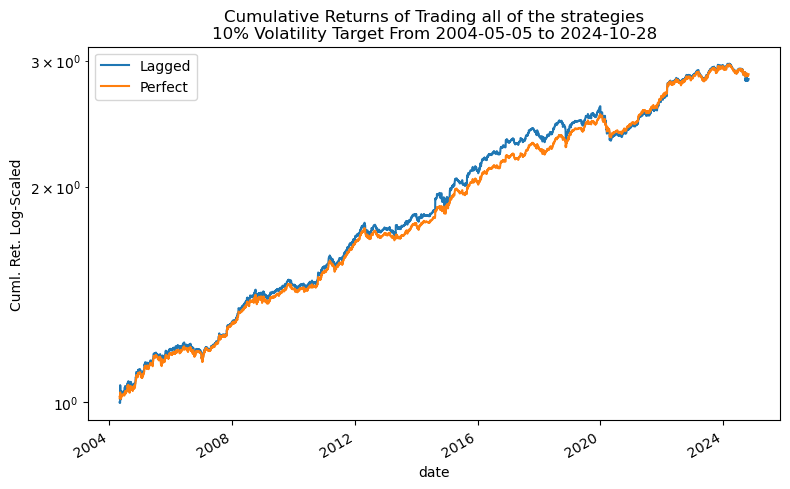

In [67]:
(df_avg_port.assign(
    vol = lambda x: x.vol.str.capitalize()).
    rename(columns = {"vol": ""}).
    pivot(index = "date", columns = "", values = "value").
    fillna(0).
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        figsize = (8,5),
        title   = "Cumulative Returns of Trading all of the strategies\n10% Volatility Target From {} to {}".format(
            df_avg_port.date.min().date(),
            df_avg_port.date.max().date())))

plt.tight_layout()

In [68]:
(df_avg_port.drop(
    columns = ["date"]).
    rename(columns = {"vol": ""}).
    groupby("").
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    rename(columns = {"value": "Sharpe"}).
    T.
    replace({
        "lagged" : "Lagged Target",
        "perfect": "Perfect Target"}).
    apply(lambda x: np.round(x,3)))

,lagged,perfect
Sharpe,1.123,1.407
